In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    precision_score, 
    accuracy_score, 
    recall_score,
)
from imblearn.over_sampling import ADASYN

In [106]:
df=pd.read_csv('train_apps.csv',sep=',')
df_feature=df[['cnt_deb_ul_ip_90','cnt_cred_loan_90','fl_hdb_bki_total_active_products','target_value']].copy()
df_feature

,cnt_deb_ul_ip_90,cnt_cred_loan_90,fl_hdb_bki_total_active_products,target_value
0,NaN,NaN,NaN,0
1,-4.466656,0.000000,NaN,0
2,5.291707,0.000000,NaN,0
3,NaN,NaN,NaN,0
4,-1.373655,6.729738,NaN,0
...,...,...,...,...
145236,2.599715,0.000000,1.302069,0
145237,-1.037194,0.000000,-4.700790,0
145238,2.863267,8.491984,-1.351879,0
145239,0.238218,16.983968,1.674455,0


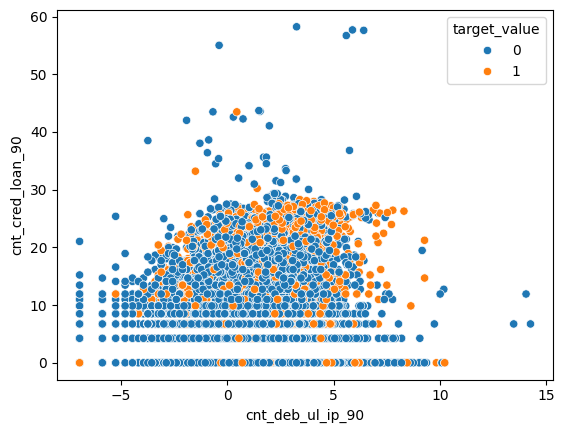

In [107]:
sns.scatterplot(data=df_feature,x='cnt_deb_ul_ip_90',y='cnt_cred_loan_90',hue='target_value');


<Axes: xlabel='fl_hdb_bki_total_active_products', ylabel='Count'>

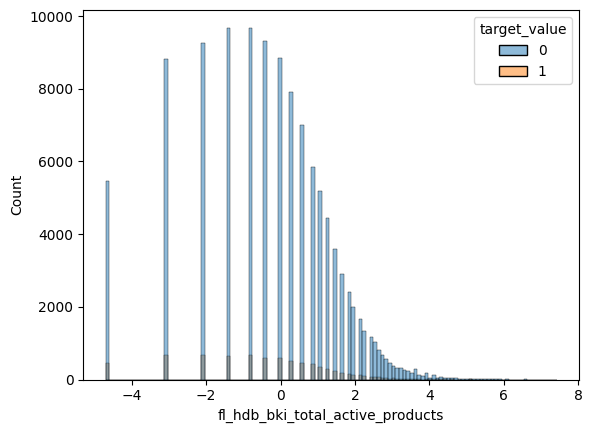

In [108]:
sns.histplot(data=df_feature,x='fl_hdb_bki_total_active_products',hue='target_value')

In [109]:
df_feature.isnull().sum()

cnt_deb_ul_ip_90                    30305
cnt_cred_loan_90                    31458
fl_hdb_bki_total_active_products    24368
target_value                            0
dtype: int64

In [110]:
df['cnt_deb_ul_ip_90'].describe()


count    114936.000000
mean         -0.358329
std           2.807625
min          -6.953811
25%          -1.979500
50%           0.147288
75%           1.645358
max          14.265022
Name: cnt_deb_ul_ip_90, dtype: float64

<Axes: xlabel='cnt_deb_ul_ip_90', ylabel='Count'>

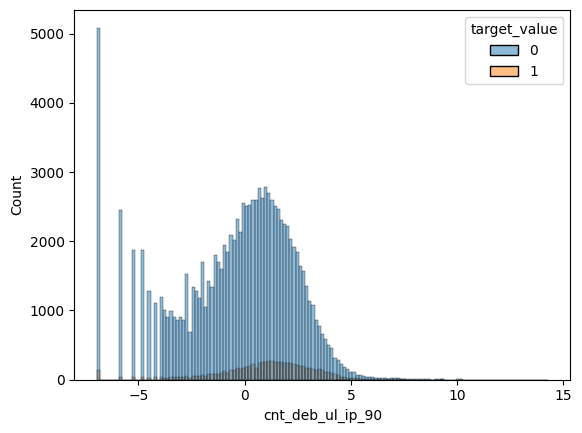

In [111]:
sns.histplot(data=df_feature,x='cnt_deb_ul_ip_90',hue='target_value')

In [112]:
df_feature=df_feature.drop(columns=['target_value'],axis=1)
df_feature

,cnt_deb_ul_ip_90,cnt_cred_loan_90,fl_hdb_bki_total_active_products
0,NaN,NaN,NaN
1,-4.466656,0.000000,NaN
2,5.291707,0.000000,NaN
3,NaN,NaN,NaN
4,-1.373655,6.729738,NaN
...,...,...,...
145236,2.599715,0.000000,1.302069
145237,-1.037194,0.000000,-4.700790
145238,2.863267,8.491984,-1.351879
145239,0.238218,16.983968,1.674455


In [113]:
df['cnt_deb_ul_ip_90'].nsmallest(10)

10    -6.953811
30    -6.953811
35    -6.953811
43    -6.953811
44    -6.953811
50    -6.953811
70    -6.953811
81    -6.953811
98    -6.953811
100   -6.953811
Name: cnt_deb_ul_ip_90, dtype: float64

In [114]:
df['cnt_deb_ul_ip_90'].nlargest(10)

60055     14.265022
64268     14.055714
77074     13.474232
118598    10.228061
120702    10.228061
28233     10.186111
21340     10.123511
56252     10.100749
37976     10.084002
49817     10.013823
Name: cnt_deb_ul_ip_90, dtype: float64

In [115]:
df_feature['cnt_deb_ul_ip_90'] = df_feature['cnt_deb_ul_ip_90'].fillna(df_feature['cnt_deb_ul_ip_90'].median())
df_feature['cnt_deb_ul_ip_90'].describe()

count    145241.000000
mean         -0.252830
std           2.506032
min          -6.953811
25%          -1.253176
50%           0.147288
75%           1.241687
max          14.265022
Name: cnt_deb_ul_ip_90, dtype: float64

In [116]:
df_feature['cnt_cred_loan_90'].isnull().sum()

np.int64(31458)

In [117]:
df_feature['cnt_cred_loan_90'].describe()

count    113783.000000
mean          2.697047
std           5.403952
min           0.000000
25%           0.000000
50%           0.000000
75%           4.245992
max          58.230575
Name: cnt_cred_loan_90, dtype: float64

In [118]:
df_feature['cnt_cred_loan_90_flag']=df_feature['cnt_cred_loan_90'].isna().astype(int)
df_feature['cnt_cred_loan_90'] = df_feature['cnt_cred_loan_90'].fillna(df_feature['cnt_cred_loan_90'].median())
df_feature['cnt_cred_loan_90'].describe()


count    145241.000000
mean          2.112889
std           4.910383
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          58.230575
Name: cnt_cred_loan_90, dtype: float64

In [119]:
df_feature['fl_hdb_bki_total_active_products'].describe()

count    120873.000000
mean         -0.216002
std           1.892380
min          -4.700790
25%          -1.351879
50%           0.000000
75%           1.091873
max           7.419594
Name: fl_hdb_bki_total_active_products, dtype: float64

In [120]:
df_feature['fl_hdb_bki_total_active_products'].isnull().sum()


np.int64(24368)

In [121]:
df_feature['fl_hdb_bki_total_active_products'] = df_feature['fl_hdb_bki_total_active_products'].fillna(df_feature['fl_hdb_bki_total_active_products'].median())
df_feature['fl_hdb_bki_total_active_products'].describe()

count    145241.000000
mean         -0.179762
std           1.728233
min          -4.700790
25%          -0.812825
50%           0.000000
75%           0.861630
max           7.419594
Name: fl_hdb_bki_total_active_products, dtype: float64

In [122]:
df_feature.isnull().sum()

cnt_deb_ul_ip_90                    0
cnt_cred_loan_90                    0
fl_hdb_bki_total_active_products    0
cnt_cred_loan_90_flag               0
dtype: int64

In [123]:
X_features_str=df[['db_group_last']]
X_features_str_db_group_last=df[['db_group_last']].fillna('Unknown')
Encoder=OneHotEncoder(drop='first',handle_unknown='ignore')
Encoder.fit(X_features_str_db_group_last)
X_features_str_db_group_last=Encoder.transform(X_features_str_db_group_last)
X_features_str_db_group_last=pd.DataFrame.sparse.from_spmatrix(data=X_features_str_db_group_last,columns=Encoder.get_feature_names_out())
X_features_str_db_group_last

,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,0,0,0,0,1.0,0,0,0,0
1,0,0,0,1.0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
145236,0,0,0,0,0,0,0,0,1.0
145237,0,0,0,1.0,0,0,0,0,0
145238,0,0,0,1.0,0,0,0,0,0
145239,0,0,0,1.0,0,0,0,0,0


In [124]:
X_features_str_fl_adminarea=df[['fl_adminarea']]
X_features_str_fl_adminarea=X_features_str_fl_adminarea[['fl_adminarea']].fillna('Unknown')
Encoder_f1=OneHotEncoder(drop='first',handle_unknown='ignore')
Encoder_f1.fit(X_features_str_fl_adminarea)
X_features_str_fl_adminarea=Encoder_f1.transform(X_features_str_fl_adminarea)
X_features_str_fl_adminarea=pd.DataFrame.sparse.from_spmatrix(X_features_str_fl_adminarea,columns=Encoder_f1.get_feature_names_out())
X_features_str_fl_adminarea

,fl_adminarea_Алтайский край,fl_adminarea_Амурская область,fl_adminarea_Архангельская область,fl_adminarea_Астраханская область,fl_adminarea_Белгородская область,fl_adminarea_Брянская область,fl_adminarea_Владимирская область,fl_adminarea_Волгоградская область,fl_adminarea_Вологодская область,fl_adminarea_Воронежская область,...,fl_adminarea_Хабаровский край,fl_adminarea_Ханты-Мансийский автономный окр.,fl_adminarea_Челябинская область,fl_adminarea_Чеченская Республика,fl_adminarea_Чувашская Республика - Чувашия,fl_adminarea_Ямало - Ненецкий автономный округ,fl_adminarea_Ярославская область,fl_adminarea_г. Москва,fl_adminarea_г. Санкт - Петербург,fl_adminarea_г. Севастополь
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
145237,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0,0
145238,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,0
145239,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [125]:
X=df[['loan_amount_last','overdraft_limit_min','overdraft_limit_max','offered_rate','cb_rate']]

In [126]:
X = X.copy()
X['offered_rate'] = X['offered_rate'].mask(X['offered_rate'] < -50,-9999)
X['offered_rate'] = X['offered_rate'].mask(X['offered_rate'] > 50,9999)
X['offered_rate'].describe()

count    145241.000000
mean          6.165663
std        1438.483661
min       -9999.000000
25%          -2.129309
50%          -0.177442
75%           1.774424
max        9999.000000
Name: offered_rate, dtype: float64

In [127]:
X_features_after=pd.concat([X,df_feature,X_features_str_fl_adminarea,X_features_str_db_group_last],axis=1)
X_features_after

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,cnt_deb_ul_ip_90,cnt_cred_loan_90,fl_hdb_bki_total_active_products,cnt_cred_loan_90_flag,fl_adminarea_Алтайский край,...,fl_adminarea_г. Севастополь,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,1.339991,-1.847954,-1.586546,1.774424,-0.400695,0.147288,0.000000,0.000000,1,0,...,0,0,0,0,0,1.0,0,0,0,0
1,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,-4.466656,0.000000,0.000000,0,0,...,0,0,0,0,1.0,0,0,0,0,0
2,2.185431,3.167063,2.369547,-0.709770,-0.400695,5.291707,0.000000,0.000000,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,0.147288,0.000000,0.000000,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0.845440,4.559196,3.467730,-2.484194,-0.400695,-1.373655,6.729738,0.000000,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,1.339991,2.480726,1.828130,3.903733,1.602779,2.599715,0.000000,1.302069,0,0,...,0,0,0,0,0,0,0,0,0,1.0
145237,0.845440,3.639458,3.605443,1.596982,1.602779,-1.037194,0.000000,-4.700790,0,0,...,0,0,0,0,1.0,0,0,0,0,0
145238,1.690880,3.960429,2.995393,3.903733,1.602779,2.863267,8.491984,-1.351879,0,0,...,0,0,0,0,1.0,0,0,0,0,0
145239,0.845440,-2.742346,-2.292086,2.661636,1.602779,0.238218,16.983968,1.674455,0,0,...,0,0,0,0,1.0,0,0,0,0,0


In [128]:
# from sklearn.model_selection import train_test_split
# y=df['target_value']
# X_features_after = X_features_after.astype(float)
# X_train,X_test,y_train,y_test=train_test_split(X_features_after,y,test_size=0.3,stratify=y)
# scaler=StandardScaler()
# labels_features=['loan_amount_last','overdraft_limit_min','overdraft_limit_max','cb_rate',
#                  'cnt_deb_ul_ip_90',
#                  'cnt_cred_loan_90',
#                  'fl_hdb_bki_total_active_products']
# for i in labels_features:
#     scaler.fit(X_train[[i]])
#     X_train[i]=scaler.transform(X_train[[i]])
#     X_test[i]=scaler.transform(X_test[[i]])
# X_train

In [129]:

# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import roc_auc_score
# Boost=GradientBoostingClassifier(subsample=0.6,
#  n_estimators=200,
#  max_features='sqrt',
#  max_depth=3,
#  loss='exponential',
#  learning_rate=0.2)
# Boost.fit(X_train,y_train)
# y_pred_proba = Boost.predict_proba(X_test)[:, 1]
# y_train_pred_proba = Boost.predict_proba(X_train)[:, 1]
# roc_auc_score(y_test,y_pred_proba)

In [130]:
# roc_auc_score(y_train,y_train_pred_proba)

In [131]:
y=df['target_value']
X_features_after = X_features_after.astype(float)
scaler=StandardScaler()
labels_features=['loan_amount_last','overdraft_limit_min','overdraft_limit_max','cb_rate',
                 'cnt_deb_ul_ip_90',
                 'cnt_cred_loan_90',
                 'fl_hdb_bki_total_active_products']
X_features_after[labels_features] = scaler.fit_transform(X_features_after[labels_features])
X_features_after


,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,cnt_deb_ul_ip_90,cnt_cred_loan_90,fl_hdb_bki_total_active_products,cnt_cred_loan_90_flag,fl_adminarea_Алтайский край,...,fl_adminarea_г. Севастополь,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,0.850468,-0.618370,-0.631264,1.774424,-0.789038,0.159663,-0.430292,0.104015,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-1.798102,-1.075713,-1.085352,1.774424,-0.789038,-1.681479,-0.430292,0.104015,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.390234,1.135186,1.109811,-0.709770,-0.789038,2.212485,-0.430292,0.104015,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.942595,-0.879915,-0.890947,1.774424,-0.789038,0.159663,-0.430292,0.104015,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.534725,1.621960,1.593122,-2.484194,-0.789038,-0.447252,0.940225,0.104015,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,0.850468,0.895200,0.871534,3.903733,1.693668,1.138276,-0.430292,0.857428,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
145237,0.534725,1.300364,1.653729,1.596982,1.693668,-0.312992,-0.430292,-2.615992,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
145238,1.074491,1.412595,1.385246,3.903733,1.693668,1.243443,1.299108,-0.678220,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
145239,0.534725,-0.931104,-0.941772,2.661636,1.693668,0.195947,3.028507,1.072901,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [132]:
# oversampling = ADASYN(
#     sampling_strategy='auto', # samples only the minority class
#         random_state=0,
#         n_neighbors=5
#         )

# X_resampled, y_resampled = oversampling.fit_resample(X_features_after, y)

In [133]:
from sklearn.ensemble import GradientBoostingClassifier
Boost=GradientBoostingClassifier(subsample=0.6,
 n_estimators=200,
 max_features='sqrt',
 max_depth=3,
 loss='exponential',
 learning_rate=0.2)
Boost.fit(X_features_after,y)
y_prod_fit=Boost.predict_proba(X_features_after)[:, 1]
roc_auc_score(y,y_prod_fit)


0.8107216258566355

In [134]:
df_test=pd.read_csv('test_apps.csv',sep=',')
idx= df_test['front_id']

In [135]:
df_feature_test=df_test[['cnt_deb_ul_ip_90','cnt_cred_loan_90','fl_hdb_bki_total_active_products']].copy()
df_feature_test

,cnt_deb_ul_ip_90,cnt_cred_loan_90,fl_hdb_bki_total_active_products
0,-2.990049,4.245992,2.653948
1,-6.953811,0.000000,-1.351879
2,NaN,NaN,-1.351879
3,NaN,NaN,-0.372386
4,NaN,NaN,NaN
...,...,...,...
36306,NaN,NaN,NaN
36307,1.597250,0.000000,NaN
36308,NaN,NaN,NaN
36309,-2.875526,0.000000,NaN


In [136]:
df_feature_test['cnt_deb_ul_ip_90'] = df_feature_test['cnt_deb_ul_ip_90'].fillna(df_feature_test['cnt_deb_ul_ip_90'].median())
df_feature_test['cnt_cred_loan_90_flag']=df_feature_test['cnt_cred_loan_90'].isna().astype(int)
df_feature_test['cnt_cred_loan_90'] = df_feature_test['cnt_cred_loan_90'].fillna(df_feature['cnt_cred_loan_90'].median())
df_feature_test['fl_hdb_bki_total_active_products'] = df_feature_test['fl_hdb_bki_total_active_products'].fillna(df_feature_test['fl_hdb_bki_total_active_products'].median())


In [137]:
X_features_str_db_group_last_test=df_test[['db_group_last']].fillna('Unknown')
X_features_str_db_group_last_test=Encoder.transform(X_features_str_db_group_last_test)
X_features_str_db_group_last_test=pd.DataFrame.sparse.from_spmatrix(data=X_features_str_db_group_last_test,columns=Encoder.get_feature_names_out())
X_features_str_db_group_last_test

,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,0,0,0,1.0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,1.0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,1.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
36306,0,0,0,0,0,0,0,0,0
36307,0,0,0,0,0,0,0,0,0
36308,0,0,0,1.0,0,0,0,0,0
36309,0,0,0,0,0,0,0,0,0


In [138]:

X_features_str_fl_adminarea_test=df_test[['fl_adminarea']].fillna('Unknown')
X_features_str_fl_adminarea_test=Encoder_f1.transform(X_features_str_fl_adminarea_test)
X_features_str_fl_adminarea_test=pd.DataFrame.sparse.from_spmatrix(X_features_str_fl_adminarea_test,columns=Encoder_f1.get_feature_names_out())
X_features_str_fl_adminarea_test

,fl_adminarea_Алтайский край,fl_adminarea_Амурская область,fl_adminarea_Архангельская область,fl_adminarea_Астраханская область,fl_adminarea_Белгородская область,fl_adminarea_Брянская область,fl_adminarea_Владимирская область,fl_adminarea_Волгоградская область,fl_adminarea_Вологодская область,fl_adminarea_Воронежская область,...,fl_adminarea_Хабаровский край,fl_adminarea_Ханты-Мансийский автономный окр.,fl_adminarea_Челябинская область,fl_adminarea_Чеченская Республика,fl_adminarea_Чувашская Республика - Чувашия,fl_adminarea_Ямало - Ненецкий автономный округ,fl_adminarea_Ярославская область,fl_adminarea_г. Москва,fl_adminarea_г. Санкт - Петербург,fl_adminarea_г. Севастополь
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36306,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36307,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36308,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36309,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [139]:
X_test=df_test[['loan_amount_last','overdraft_limit_min','overdraft_limit_max','offered_rate','cb_rate']]

In [140]:
X_test = X_test.copy()
X_test['offered_rate'] = X_test['offered_rate'].mask(X_test['offered_rate'] < -50,-9999)
X_test['offered_rate'] = X_test['offered_rate'].mask(X_test['offered_rate'] > 50,9999)
X_test['offered_rate'].describe()

count    36311.000000
mean        47.037126
std       4394.732909
min      -9999.000000
25%         -0.354885
50%          0.532327
75%          1.951866
max       9999.000000
Name: offered_rate, dtype: float64

In [141]:
X_features_after_test=pd.concat([X_test,df_feature_test,X_features_str_fl_adminarea_test,X_features_str_db_group_last_test],axis=1)
X_features_after_test

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,cnt_deb_ul_ip_90,cnt_cred_loan_90,fl_hdb_bki_total_active_products,cnt_cred_loan_90_flag,fl_adminarea_Алтайский край,...,fl_adminarea_г. Севастополь,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,0.000000,1.480173,1.038845,0.709770,1.602779,-2.990049,4.245992,2.653948,0,0,...,0,0,0,0,1.0,0,0,0,0,0
1,0.961691,2.573324,1.901177,2.306751,1.602779,-6.953811,0.000000,-1.351879,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.623060,-3.719511,-3.062922,1.596982,1.602779,-0.526853,0.000000,-1.351879,1,0,...,0,0,0,0,1.0,0,0,0,0,0
3,0.000000,1.526705,1.075552,9999.000000,1.602779,-0.526853,0.000000,-0.372386,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2.185431,1.998064,1.447383,3.371406,1.602779,-0.526853,0.000000,-0.372386,1,0,...,0,0,0,0,1.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36306,2.185431,-0.163767,2.884872,0.177442,-0.200347,-0.526853,0.000000,-0.372386,1,0,...,0,0,0,0,0,0,0,0,0,0
36307,1.690880,3.892473,2.941786,9999.000000,-0.200347,1.597250,0.000000,-0.372386,0,0,...,0,0,0,0,0,0,0,0,0,0
36308,1.339991,1.444637,1.010812,2.484194,-0.200347,-0.526853,0.000000,-0.372386,1,0,...,0,0,0,0,1.0,0,0,0,0,0
36309,0.716931,3.906632,2.952955,0.177442,-0.200347,-2.875526,0.000000,-0.372386,0,0,...,0,0,0,0,0,0,0,0,0,0


In [142]:
X_features_after_test = X_features_after_test.astype(float)
labels_features=['loan_amount_last','overdraft_limit_min','overdraft_limit_max','cb_rate',
                 'cnt_deb_ul_ip_90',
                 'cnt_cred_loan_90',
                 'fl_hdb_bki_total_active_products']
X_features_after_test[labels_features] = scaler.transform(X_features_after_test[labels_features])
X_features_after_test

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,cnt_deb_ul_ip_90,cnt_cred_loan_90,fl_hdb_bki_total_active_products,cnt_cred_loan_90_flag,fl_adminarea_Алтайский край,...,fl_adminarea_г. Севастополь,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,-0.005041,0.545346,0.524170,0.709770,1.693668,-1.092256,0.434408,1.639663,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.608945,0.927578,0.903682,2.306751,1.693668,-2.673950,-0.430292,-0.678220,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.402829,-1.272781,-1.281017,1.596982,1.693668,-0.109346,-0.430292,-0.678220,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.005041,0.561616,0.540325,9999.000000,1.693668,-0.109346,-0.430292,-0.111458,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.390234,0.726432,0.703967,3.371406,1.693668,-0.109346,-0.430292,-0.111458,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36306,1.390234,-0.029476,1.336606,0.177442,-0.540768,-0.109346,-0.430292,-0.111458,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36307,1.074491,1.388833,1.361654,9999.000000,-0.540768,0.738253,-0.430292,-0.111458,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36308,0.850468,0.532920,0.511833,2.484194,-0.540768,-0.109346,-0.430292,-0.111458,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
36309,0.452679,1.393784,1.366569,0.177442,-0.540768,-1.046557,-0.430292,-0.111458,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [143]:
df_out = pd.DataFrame()
df_out['front_id'] = idx
df_out['target_value'] = Boost.predict_proba(X_features_after_test)[:, 1]
df_out.to_csv('submission.csv', index=False)